# 21CSC305P Machine Learning Lab - Personalised Nutrition Recommender

**Problem.** People who want to eat to a calorie target face two separate
questions: *how much* should I eat, and *what* should I eat that I will
actually enjoy? Most diet apps answer the first with a formula and the second
with a fixed list. This project answers both from real data:

- a daily calorie and macronutrient target, checked against what real adults
  report eating;
- recipe recommendations learned from 220,000 reviews on Food.com;
- meal plans that hit the target using the recommended recipes.

Every lab program is applied to this one problem.

**Datasets**

| Dataset | What it holds | Size after cleaning |
|---|---|---|
| Food.com Recipes and Interactions (Majumder et al., 2019), 2008-2018 | recipes with ingredients, tags and nutrition per serving; user reviews with 0-5 stars | 78,930 recipes, 221,732 reviews |
| NHANES 2017-2018 (US CDC) | measured weight and height, activity questionnaire, two 24-hour dietary recalls | 3,811 adults |

**Programs**

| Program | Method | Applied to |
|---|---|---|
| 1 | Load and view | recipes, reviews, survey |
| 2 | Summary statistics | nutrition sanity checks, cleaning rules, long tail of reviews |
| 3 | Linear regression | daily energy intake from age, sex, body size and activity |
| 4.1 | Bayesian logistic regression | P(dessert) from nutrient profile, with credible intervals |
| 4.2 | SVM | recipe course from ingredients and nutrition; fills missing course tags |
| 5.1 | K-means | nutrition archetypes of recipes |
| 5.2 | Gaussian mixture model | taste segments of users |
| 5.3 | Hierarchical clustering | ingredients that are cooked together |
| 6 | PCA / truncated SVD | recipe nutrition map; latent factors of the review matrix |
| 7 | Hidden Markov Model | hidden eating phases in a user's review history |
| 8 | CART | archetypes as readable threshold rules |
| 9 | Ensemble learning | the ranking stage of the recommender |

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
FIG = ROOT / "outputs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

import ast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from archetypes import Archetypes
from course import build_course_model, course_frame, fill_courses, fit_course_model
from energy import daily_target, fit_intake_model, intake_features, load_nhanes
from planner import plan_meals
from recipes import (
    ATWATER_RANGE, DAILY_VALUE, DATA_DIR, KCAL_RANGE, MAX_MINUTES, NUTRIENT_FEATURES,
    NUTRITION_FIELDS, load_interactions, load_recipes,
)
from recommender import (
    FEATURES, Evaluation, HybridRecommender, ItemIndex, history_matrix,
    interaction_matrix, pool_ranks, ranker_models, ranking_metrics, sample_negatives,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
warnings.filterwarnings("ignore", category=UserWarning)


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")

## Program 1 - Load and view the dataset

The raw Food.com files store lists (tags, ingredients, steps, nutrition) as
Python-literal strings. `recipes.load_recipes` parses them, converts the
nutrition panel from percent daily value to grams and applies the cleaning
rules justified in Program 2.

In [2]:
raw_recipes = pd.read_csv(DATA_DIR / "RAW_recipes.csv")
raw_interactions = pd.read_csv(DATA_DIR / "RAW_interactions.csv")
print(f"raw recipes {raw_recipes.shape}, raw reviews {raw_interactions.shape}")
raw_recipes[["name", "id", "minutes", "tags", "nutrition", "n_ingredients"]].head(3)

raw recipes (83782, 12), raw reviews (731927, 5)


,name,id,minutes,tags,nutrition,n_ingredients
0,1 brownies in the world best ever,333281,40,"['60-minutes-or-less', 'time-to-make', 'course...","[138.4, 10.0, 50.0, 3.0, 3.0, 19.0, 6.0]",9
1,1 in canada chocolate chip cookies,453467,45,"['60-minutes-or-less', 'time-to-make', 'cuisin...","[595.1, 46.0, 211.0, 22.0, 13.0, 51.0, 26.0]",11
2,412 broccoli casserole,306168,40,"['60-minutes-or-less', 'time-to-make', 'course...","[194.8, 20.0, 6.0, 32.0, 22.0, 36.0, 3.0]",9


In [3]:
raw_interactions.head(3)

,user_id,recipe_id,date,rating,review
0,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
1,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
2,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


In [4]:
recipes = load_recipes()
interactions = load_interactions(recipes["recipe_id"])
nhanes = load_nhanes()
print(
    f"{len(recipes):,} recipes, {len(interactions):,} reviews by "
    f"{interactions['user_id'].nunique():,} users, {len(nhanes):,} NHANES adults"
)
recipes[["title", "course", "minutes", "n_ingredients", "calories", "protein_g",
         "carbs_g", "fat_g", "sugar_g", "sodium_mg"]].head()

78,930 recipes, 221,732 reviews by 64,643 users, 3,811 NHANES adults


,title,course,minutes,n_ingredients,calories,protein_g,carbs_g,fat_g,sugar_g,sodium_mg
0,1 Brownies In The World Best Ever,dessert,40,9,138.4,1.5,18.0,6.50,12.50,72.0
1,1 In Canada Chocolate Chip Cookies,NaN,45,11,595.1,6.5,78.0,29.90,52.75,528.0
2,412 Broccoli Casserole,side,40,9,194.8,11.0,9.0,13.00,1.50,768.0
3,Millionaire Pound Cake,dessert,120,7,878.3,10.0,117.0,40.95,81.50,312.0
4,2000 Meatloaf,main,90,13,267.0,14.5,6.0,19.50,3.00,288.0


In [5]:
nhanes.head()

,SEQN,age,sex,male,weight,height,bmi,met_minutes,activity,bmr,formula_tdee,intake,recall_days,protein_g,carbs_g,fat_g
0,93705.0,66.0,female,0,79.5,158.3,31.7,480.0,sedentary,1293.375,1552.05000,1218.5,2,20.01,157.45,56.98
1,93708.0,66.0,female,0,53.5,150.2,23.7,600.0,sedentary,982.750,1179.30000,1046.5,2,50.96,123.71,65.49
2,93711.0,56.0,male,1,62.1,170.6,21.3,3360.0,active,1412.250,2436.13125,2829.5,2,101.33,339.60,124.24
3,93713.0,67.0,male,1,74.9,178.6,23.5,1080.0,light,1535.250,2110.96875,2167.0,1,61.40,201.09,114.30
4,93716.0,61.0,male,1,77.7,159.2,30.7,3840.0,active,1472.000,2539.20000,2750.0,2,103.91,442.98,85.06


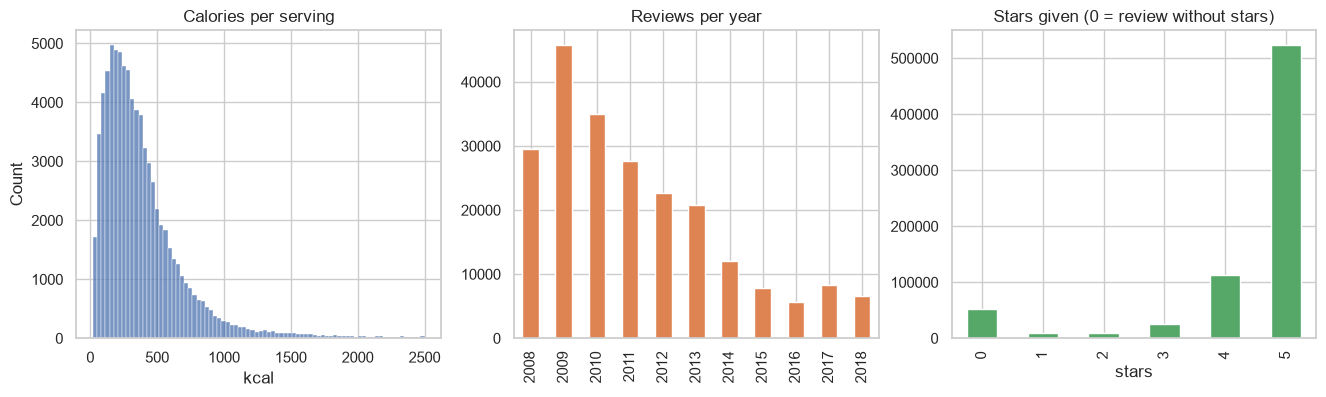

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(recipes["calories"], bins=80, ax=axes[0])
axes[0].set(title="Calories per serving", xlabel="kcal")
interactions["date"].dt.year.value_counts().sort_index().plot.bar(ax=axes[1], color="C1")
axes[1].set(title="Reviews per year", xlabel="")
raw_interactions["rating"].value_counts().sort_index().plot.bar(ax=axes[2], color="C2")
axes[2].set(title="Stars given (0 = review without stars)", xlabel="stars")
save(fig, "p1_overview")

## Program 2 - Summary and statistics of the dataset

Food.com's nutrition is entered by recipe authors and computed by the site, so
it has to be checked before any model trusts it. Energy should equal
4 kcal/g protein + 4 kcal/g carbohydrate + 9 kcal/g fat (the Atwater factors).
Rows that break this, rows where the whole recipe was entered as a single
serving, and rows with impossible cooking times are removed.

In [7]:
nutrition = pd.DataFrame(raw_recipes["nutrition"].map(ast.literal_eval).tolist(), columns=NUTRITION_FIELDS)
for col, dv in DAILY_VALUE.items():
    nutrition[col] = nutrition[col] / 100 * dv
atwater = 4 * nutrition["protein_g"] + 4 * nutrition["carbs_g"] + 9 * nutrition["fat_g"]
ratio = atwater / nutrition["calories"].where(nutrition["calories"] > 0)

rules = pd.Series({
    f"calories outside {KCAL_RANGE[0]}-{KCAL_RANGE[1]} per serving": (~nutrition["calories"].between(*KCAL_RANGE)).sum(),
    "stated calories disagree with macros by more than 30%": (~ratio.between(*ATWATER_RANGE)).sum(),
    "cooking time 0 or over 24 hours": (~raw_recipes["minutes"].between(1, MAX_MINUTES)).sum(),
}, name="rows failing (rules overlap)")
print(rules.to_string())
print(f"\nmedian Atwater / stated calories: {ratio.median():.3f}")
print(f"kept {len(recipes):,} of {len(raw_recipes):,} recipes ({len(recipes) / len(raw_recipes):.1%})")

calories outside 20-2500 per serving                     2047
stated calories disagree with macros by more than 30%    3130
cooking time 0 or over 24 hours                           589

median Atwater / stated calories: 0.980
kept 78,930 of 83,782 recipes (94.2%)


In [8]:
recipes[["calories", "protein_g", "carbs_g", "fat_g", "sugar_g", "sodium_mg", "minutes", "n_ingredients"]].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
calories,78930.0,392.7,323.5,20.1,180.9,312.0,497.6,2500.0
protein_g,78930.0,16.2,17.8,0.0,3.5,9.5,24.5,300.5
carbs_g,78930.0,36.8,42.5,0.0,12.0,27.0,48.0,657.0
fat_g,78930.0,19.5,21.9,0.0,5.8,13.6,25.4,271.7
sugar_g,78930.0,14.1,26.6,0.0,2.2,5.8,15.0,607.8
sodium_mg,78930.0,643.9,1860.0,0.0,120.0,360.0,768.0,170256.0
minutes,78930.0,63.2,97.1,1.0,20.0,35.0,60.0,1440.0
n_ingredients,78930.0,9.3,3.8,1.0,7.0,9.0,12.0,33.0


half of recipes have at most 2 review(s); half of users wrote 1
review matrix density: 0.004346%


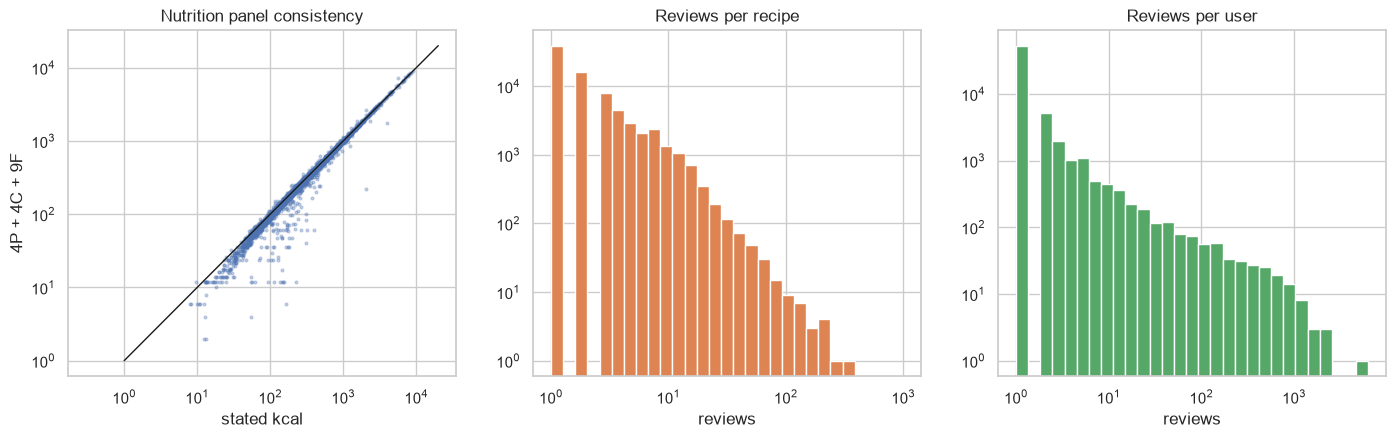

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sample = pd.DataFrame({"stated": nutrition["calories"], "atwater": atwater}).query("stated > 0").sample(6000, random_state=0)
axes[0].scatter(sample["stated"], sample["atwater"], s=4, alpha=0.3)
axes[0].plot([1, 20000], [1, 20000], color="k", lw=1)
axes[0].set(xscale="log", yscale="log", xlabel="stated kcal", ylabel="4P + 4C + 9F", title="Nutrition panel consistency")

per_recipe = interactions.groupby("recipe_id").size()
per_user = interactions.groupby("user_id").size()
axes[1].hist(per_recipe, bins=np.logspace(0, 3, 30), color="C1")
axes[1].set(xscale="log", yscale="log", title="Reviews per recipe", xlabel="reviews")
axes[2].hist(per_user, bins=np.logspace(0, 3.8, 30), color="C2")
axes[2].set(xscale="log", yscale="log", title="Reviews per user", xlabel="reviews")
save(fig, "p2_quality_and_long_tail")

density = len(interactions) / (interactions["user_id"].nunique() * len(recipes))
print(f"half of recipes have at most {per_recipe.median():.0f} review(s); half of users wrote {per_user.median():.0f}")
print(f"review matrix density: {density:.6%}")

In [10]:
pd.DataFrame({
    "recipes": recipes["course"].value_counts(dropna=False),
    "share": recipes["course"].value_counts(dropna=False, normalize=True).round(3),
})

,recipes,share
course,,
main,27284,0.346
side,13557,0.172
dessert,12674,0.161
NaN,9080,0.115
breakfast,7386,0.094
snack,3800,0.048
beverage,2765,0.035
condiment,2384,0.030


## Program 3 - Linear regression for daily energy intake

The app's calorie target comes from the Mifflin-St Jeor equation scaled by an
activity factor. Here a linear regression is fitted to what NHANES adults
actually reported eating, and both are compared against the reported intake.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split

X, y = intake_features(nhanes), nhanes["intake"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression().fit(X_train, y_train)
pred = lr.predict(X_test)
formula = nhanes.loc[X_test.index, "formula_tdee"]

print(pd.Series(lr.coef_, index=X.columns).round(2).to_string())
print(f"intercept {lr.intercept_:.1f}")
cv = cross_val_score(LinearRegression(), X, y, cv=KFold(5, shuffle=True, random_state=42), scoring="r2")
print(f"\nregression  test R2 {r2_score(y_test, pred):.3f}  RMSE {mean_squared_error(y_test, pred) ** 0.5:.0f} kcal  (5-fold CV R2 {cv.mean():.3f})")
print(f"formula     test R2 {r2_score(y_test, formula):.3f}  RMSE {mean_squared_error(y_test, formula) ** 0.5:.0f} kcal")
print(f"formula minus reported intake, mean: {(formula - y_test).mean():+.0f} kcal")

age         -2.52
male       309.55
weight       1.02
height      15.36
log_met      5.68
intercept -705.0

regression  test R2 0.139  RMSE 682 kcal  (5-fold CV R2 0.159)
formula     test R2 -0.468  RMSE 891 kcal
formula minus reported intake, mean: +313 kcal


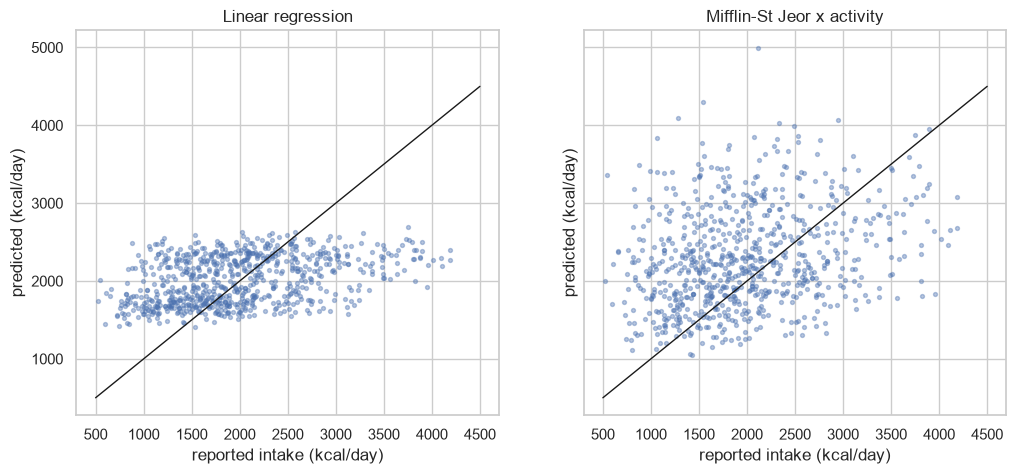

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, values, title in [(axes[0], pred, "Linear regression"), (axes[1], formula, "Mifflin-St Jeor x activity")]:
    ax.scatter(y_test, values, s=8, alpha=0.4)
    ax.plot([500, 4500], [500, 4500], color="k", lw=1)
    ax.set(title=title, xlabel="reported intake (kcal/day)", ylabel="predicted (kcal/day)")
save(fig, "p3_intake_regression")

Energy intake is hard to predict from body size alone: people eat differently
from day to day and a food recall is only one or two days. The formula
predicts *requirements*, and it sits above reported intake on average, which
matches the well-documented under-reporting in dietary recalls. The app
therefore keeps the formula as the target and shows the regression only as
context.

## Program 4.1 - Bayesian logistic regression for dessert detection

Does a recipe's nutrient profile alone say it is a dessert? A logistic
regression with a Gaussian prior N(0, 2²) on every weight is fitted by finding
the posterior mode, and the posterior is approximated by a Gaussian with
covariance equal to the inverse Hessian there (the Laplace approximation).
That gives a credible interval for every coefficient and an uncertainty band
for every prediction.

In [13]:
from scipy.optimize import minimize
from scipy.special import expit
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

tagged = recipes[recipes["course"].notna()]
data = tagged.sample(12000, random_state=42)
scaler = StandardScaler().fit(data[NUTRIENT_FEATURES])
Xb = np.column_stack([np.ones(len(data)), scaler.transform(data[NUTRIENT_FEATURES])])
yb = (data["course"] == "dessert").astype(int).to_numpy()
Xtr, Xte, ytr, yte, idx_tr, idx_te = train_test_split(Xb, yb, data.index, test_size=0.25, random_state=42, stratify=yb)

PRIOR_VAR = 2.0 ** 2


def neg_log_posterior(w):
    z = Xtr @ w
    return np.sum(np.logaddexp(0, z) - ytr * z) + w @ w / (2 * PRIOR_VAR)


def gradient(w):
    return Xtr.T @ (expit(Xtr @ w) - ytr) + w / PRIOR_VAR


w_map = minimize(neg_log_posterior, np.zeros(Xtr.shape[1]), jac=gradient, method="L-BFGS-B").x
p_tr = expit(Xtr @ w_map)
hessian = (Xtr * (p_tr * (1 - p_tr))[:, None]).T @ Xtr + np.eye(len(w_map)) / PRIOR_VAR
cov = np.linalg.inv(hessian)
sd = np.sqrt(np.diag(cov))
posterior = pd.DataFrame(
    {"mean": w_map, "sd": sd, "2.5%": w_map - 1.96 * sd, "97.5%": w_map + 1.96 * sd},
    index=["intercept"] + NUTRIENT_FEATURES,
).round(3)
posterior

,mean,sd,2.5%,97.5%
intercept,-2.654,0.065,-2.781,-2.527
protein_pct,-1.697,0.749,-3.165,-0.230
carbs_pct,0.684,1.388,-2.037,3.404
fat_pct,0.255,1.234,-2.163,2.674
sugar_pct,0.422,0.049,0.326,0.519
sat_fat_pct,0.746,0.042,0.664,0.829
log_sodium_density,-0.020,0.034,-0.087,0.046
log_kcal,0.080,0.033,0.014,0.145


In [14]:
rng = np.random.default_rng(0)
W = rng.multivariate_normal(w_map, cov, size=2000)
draws = expit(Xte @ W.T)
p_mean = draws.mean(axis=1)
lo, hi = np.percentile(draws, [2.5, 97.5], axis=1)
print(f"test accuracy {accuracy_score(yte, p_mean > 0.5):.3f}, ROC AUC {roc_auc_score(yte, p_mean):.3f}, dessert share {yte.mean():.3f}")

examples = pd.DataFrame({
    "title": recipes.loc[idx_te, "title"].to_numpy(),
    "course": recipes.loc[idx_te, "course"].to_numpy(),
    "P(dessert)": p_mean.round(3),
    "95% interval": [f"{a:.3f} - {b:.3f}" for a, b in zip(lo, hi)],
    "width": (hi - lo).round(3),
})
examples.sort_values("width", ascending=False).head(8)

test accuracy 0.828, ROC AUC 0.889, dessert share 0.180


,title,course,P(dessert),95% interval,width
1550,Melon Fever,beverage,0.432,0.361 - 0.505,0.144
2606,Amaretto And Cream,beverage,0.639,0.567 - 0.708,0.141
2602,Swedish Dried Fruit Cream,condiment,0.277,0.211 - 0.352,0.141
2836,Vietnamese Pickled Carrots And Daikon Radish,snack,0.442,0.375 - 0.513,0.137
2897,Big Bob Gibson Barbecue Ribs,main,0.574,0.505 - 0.638,0.133
1461,California Fruit Cubes,beverage,0.482,0.415 - 0.547,0.132
1655,30 Second Steak Sauce,condiment,0.660,0.592 - 0.723,0.131
390,Emily S Creamy Pepperoni Dip,breakfast,0.468,0.403 - 0.534,0.131


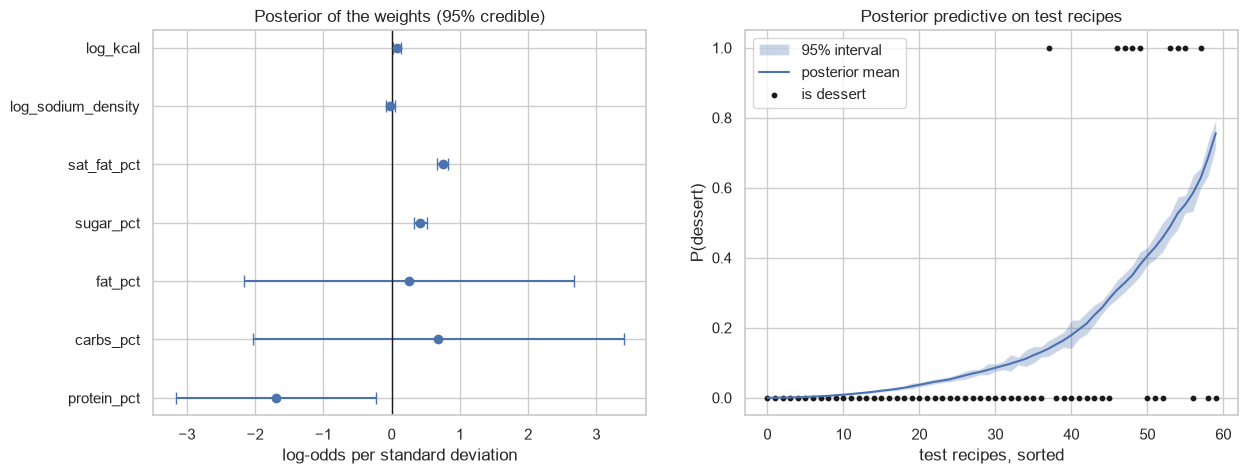

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
post = posterior.drop(index="intercept")
axes[0].errorbar(post["mean"], range(len(post)), xerr=1.96 * post["sd"], fmt="o", capsize=4)
axes[0].axvline(0, color="k", lw=1)
axes[0].set(yticks=range(len(post)), yticklabels=post.index, title="Posterior of the weights (95% credible)", xlabel="log-odds per standard deviation")

order = np.argsort(p_mean)[:: max(1, len(p_mean) // 60)]
axes[1].fill_between(range(len(order)), lo[order], hi[order], alpha=0.3, label="95% interval")
axes[1].plot(range(len(order)), p_mean[order], label="posterior mean")
axes[1].scatter(range(len(order)), yte[order], s=10, color="k", label="is dessert")
axes[1].set(title="Posterior predictive on test recipes", xlabel="test recipes, sorted", ylabel="P(dessert)")
axes[1].legend()
save(fig, "p4_bayesian_logistic")

## Program 4.2 - SVM to predict a recipe's course

About one recipe in nine has no course tag, and the meal planner cannot place
a recipe in breakfast, lunch, dinner or snack without one. A linear SVM on
TF-IDF ingredient weights plus the nutrient profile learns the course from
the tagged recipes; calibration turns its margins into probabilities so only
confident predictions are used.

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

train_c, test_c = train_test_split(tagged, test_size=0.2, stratify=tagged["course"], random_state=42)
svm = build_course_model().fit(course_frame(train_c), train_c["course"])
pred_c = svm.predict(course_frame(test_c))
print(classification_report(test_c["course"], pred_c, digits=3))

              precision    recall  f1-score   support

    beverage      0.821     0.877     0.848       553
   breakfast      0.680     0.459     0.548      1477
   condiment      0.633     0.453     0.528       477
     dessert      0.825     0.927     0.873      2535
        main      0.784     0.861     0.821      5457
        side      0.679     0.699     0.689      2711
       snack      0.595     0.322     0.418       760

    accuracy                          0.756     13970
   macro avg      0.717     0.657     0.675     13970
weighted avg      0.746     0.756     0.745     13970



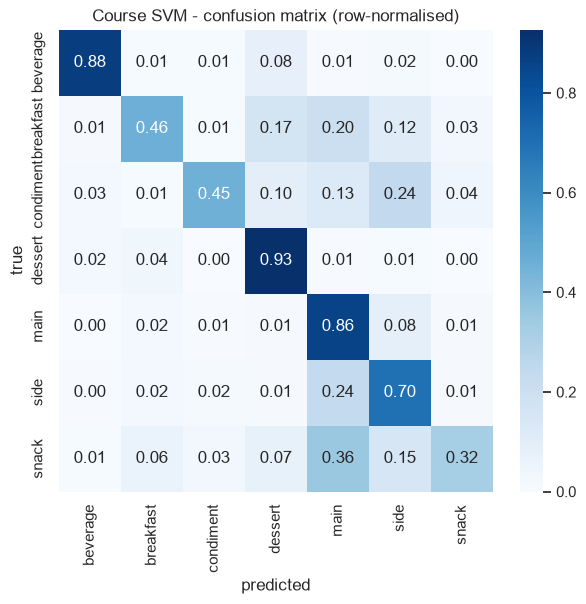

In [17]:
cm = confusion_matrix(test_c["course"], pred_c, labels=svm.classes_, normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=svm.classes_, yticklabels=svm.classes_, ax=ax)
ax.set(xlabel="predicted", ylabel="true", title="Course SVM - confusion matrix (row-normalised)")
save(fig, "p4_svm_confusion")

In [18]:
course_model = fit_course_model(recipes)
recipes = fill_courses(recipes, course_model)
print(recipes["course_source"].value_counts(dropna=False).to_string())
recipes.loc[recipes["course_source"] == "model", ["title", "course_final", "course_confidence"]].sample(8, random_state=1)

course_source
tag      69850
model     7266
NaN       1814


,title,course_final,course_confidence
28967,French Italian Fusion Chicken,main,0.901282
36936,How To Make Chapatis,main,0.587918
63109,Silver Dollar City Succotash,main,0.531889
12711,Catfish Parlour Hush Puppies,side,0.579586
15311,Chicken Pepperoni Burgers,main,0.895634
28325,Five Cheese Mac N Cheese For Grownups,main,0.578674
24282,Dinner Rolls And Hamburger Buns Gluten Free,breakfast,0.713983
60574,Salmon With Fennel Swiss Chard And Penne,main,0.921621


## Program 5.1 - K-means nutrition archetypes

Recipes are clustered on seven portion-independent features: the share of
energy from protein, carbohydrate, fat, sugar and saturated fat, log sodium
per 100 kcal, and log calories per serving. The number of clusters is chosen
by silhouette score; names are generated from each cluster centre.

,archetype,share,kcal,protein %,carbs %,fat %,sugar %,sat fat %,sodium mg/100kcal
0,Sugary & Light,0.076,139.0,10.0,75.0,14.0,48.0,5.0,138.0
1,Rich & Hearty,0.220,572.0,21.0,22.0,57.0,5.0,21.0,131.0
2,Starchy,0.193,337.0,17.0,59.0,25.0,8.0,7.0,136.0
3,Sugary & Unsalted,0.037,148.0,3.0,94.0,3.0,80.0,1.0,1.0
4,High-protein,0.097,275.0,47.0,18.0,35.0,7.0,10.0,168.0
5,Buttery,0.085,262.0,12.0,15.0,73.0,7.0,41.0,84.0
6,Unsalted & Light,0.038,162.0,8.0,45.0,47.0,16.0,11.0,0.0
7,Rich & Light,0.110,144.0,12.0,30.0,59.0,11.0,15.0,159.0
8,Sweet,0.145,357.0,6.0,52.0,42.0,33.0,21.0,53.0


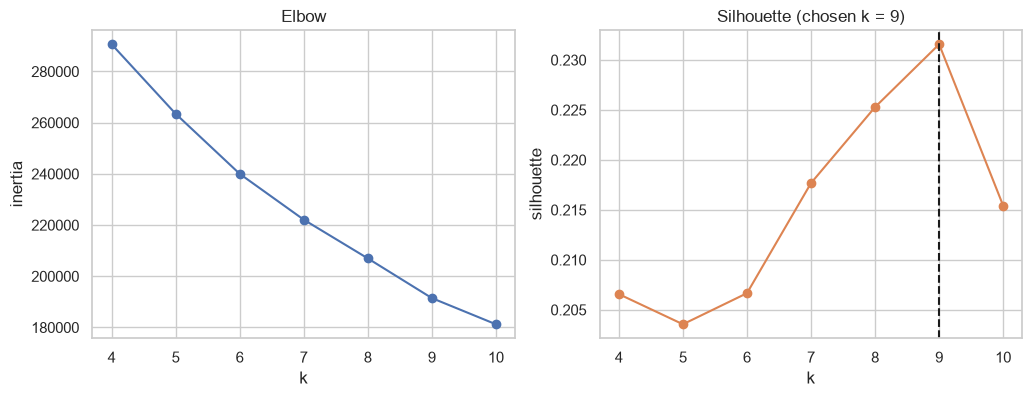

In [19]:
from sklearn.cluster import KMeans

archetypes = Archetypes().fit(recipes)
recipes["archetype"] = archetypes.label(recipes)
Z = archetypes.scaler_.transform(recipes[NUTRIENT_FEATURES])
inertia = {k: KMeans(k, n_init=10, random_state=42).fit(Z).inertia_ for k in archetypes.k_range}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(inertia), list(inertia.values()), marker="o")
axes[0].set(title="Elbow", xlabel="k", ylabel="inertia")
axes[1].plot(list(archetypes.silhouette_), list(archetypes.silhouette_.values()), marker="o", color="C1")
axes[1].axvline(archetypes.k_, color="k", ls="--")
axes[1].set(title=f"Silhouette (chosen k = {archetypes.k_})", xlabel="k", ylabel="silhouette")
save(fig, "p5_kmeans_selection")
archetypes.summary()

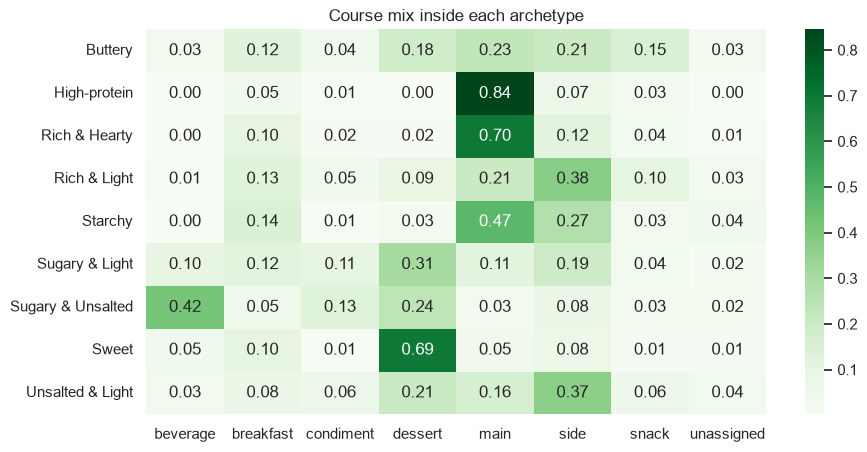

In [20]:
mix = pd.crosstab(recipes["archetype"], recipes["course_final"].fillna("unassigned"), normalize="index")
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(mix, annot=True, fmt=".2f", cmap="Greens", ax=ax)
ax.set(title="Course mix inside each archetype", xlabel="", ylabel="")
save(fig, "p5_archetype_course")

## Program 5.2 - Gaussian mixture model of user taste

Each user with at least 10 reviews is described by the share of their reviews
that fall in each archetype. Shares are square-root transformed (the Hellinger
transform) so that the many shares near zero do not dominate, and a small
covariance floor stops components collapsing onto users who never cook one
archetype. A Gaussian mixture with full covariance finds taste segments, and
its soft memberships show how many users sit clearly in one segment.

1,680 users; lowest BIC at 9 components, simplest within 2%: 5
users with a segment probability above 0.8: 95.1%


,Sugary & Light,Rich & Hearty,Starchy,Sugary & Unsalted,High-protein,Buttery,Unsalted & Light,Rich & Light,Sweet
segment 1 (182 users),0.4,-5.3,-3.4,0.8,5.0,-2.6,3.7,-1.3,2.8
segment 2 (229 users),-1.2,6.6,4.6,-1.3,3.0,1.2,0.5,0.6,-13.9
segment 3 (227 users),0.6,-1.9,1.3,0.7,-10.7,-0.6,0.5,1.0,9.1
segment 4 (437 users),-0.5,2.4,-1.2,-0.9,2.8,-0.0,-3.6,-1.7,2.8
segment 5 (605 users),0.5,-2.0,-0.3,0.7,-0.6,0.6,1.2,1.0,-1.0


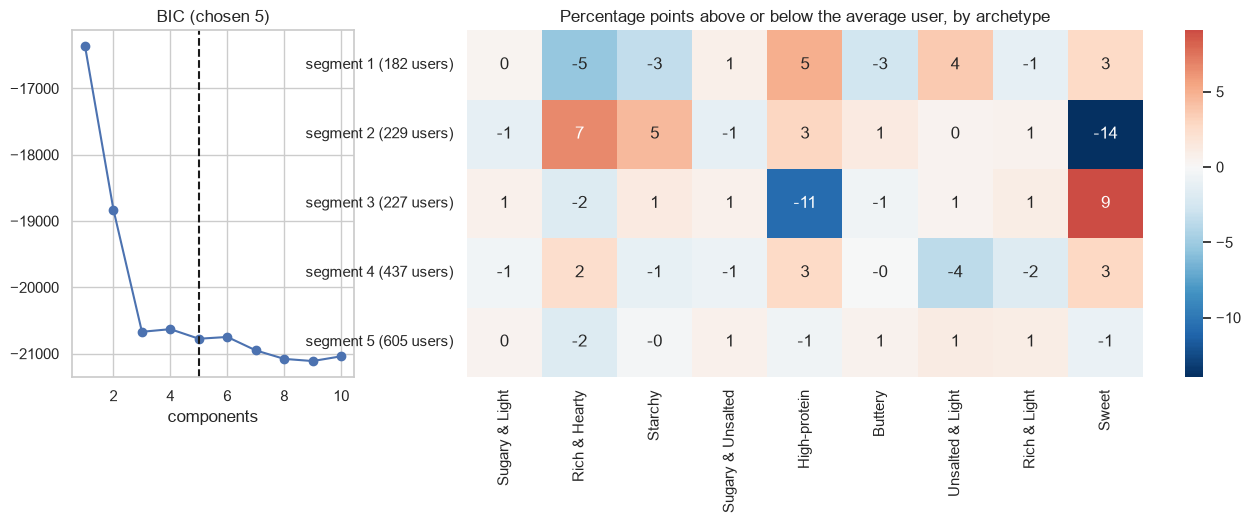

In [21]:
from sklearn.mixture import GaussianMixture

labels = pd.Series(archetypes.predict(recipes), index=recipes["recipe_id"])
inter = interactions.assign(archetype=labels.reindex(interactions["recipe_id"]).to_numpy())
per_user = inter.groupby("user_id").size()
active = inter[inter["user_id"].isin(per_user[per_user >= 10].index)]
taste = pd.crosstab(active["user_id"], active["archetype"], normalize="index")
taste.columns = [archetypes.names_[c] for c in taste.columns]

X_taste = np.sqrt(taste)


def fit_gmm(k):
    return GaussianMixture(k, covariance_type="full", reg_covar=1e-3, n_init=5, random_state=42).fit(X_taste)


bic = {k: fit_gmm(k).bic(X_taste) for k in range(1, 11)}
min_bic_k = min(bic, key=bic.get)
# BIC keeps creeping down as components are added, so take the simplest
# model whose BIC is within 2% of the best.
best_k = min(k for k, v in bic.items() if v <= bic[min_bic_k] + 0.02 * abs(bic[min_bic_k]))
gmm = fit_gmm(best_k)
resp = gmm.predict_proba(X_taste)
assigned = resp.argmax(axis=1)
print(f"{len(taste):,} users; lowest BIC at {min_bic_k} components, simplest within 2%: {best_k}")
print(f"users with a segment probability above 0.8: {(resp.max(axis=1) > 0.8).mean():.1%}")

sizes = np.bincount(assigned, minlength=best_k)
segments = taste.groupby(assigned).mean()
segments.index = [f"segment {i + 1} ({sizes[i]} users)" for i in segments.index]
difference = 100 * (segments - taste.mean())
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), gridspec_kw={"width_ratios": [1, 3]})
axes[0].plot(list(bic), list(bic.values()), marker="o")
axes[0].axvline(best_k, color="k", ls="--")
axes[0].set(title=f"BIC (chosen {best_k})", xlabel="components")
sns.heatmap(difference, annot=True, fmt=".0f", cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set(title="Percentage points above or below the average user, by archetype")
save(fig, "p5_gmm_segments")
difference.round(1)

## Program 5.3 - Hierarchical clustering of ingredients

The 60 most common ingredients (after salt, pepper and water) are clustered by
how often they appear in the same recipes: Jaccard distance between their
recipe sets, average linkage.

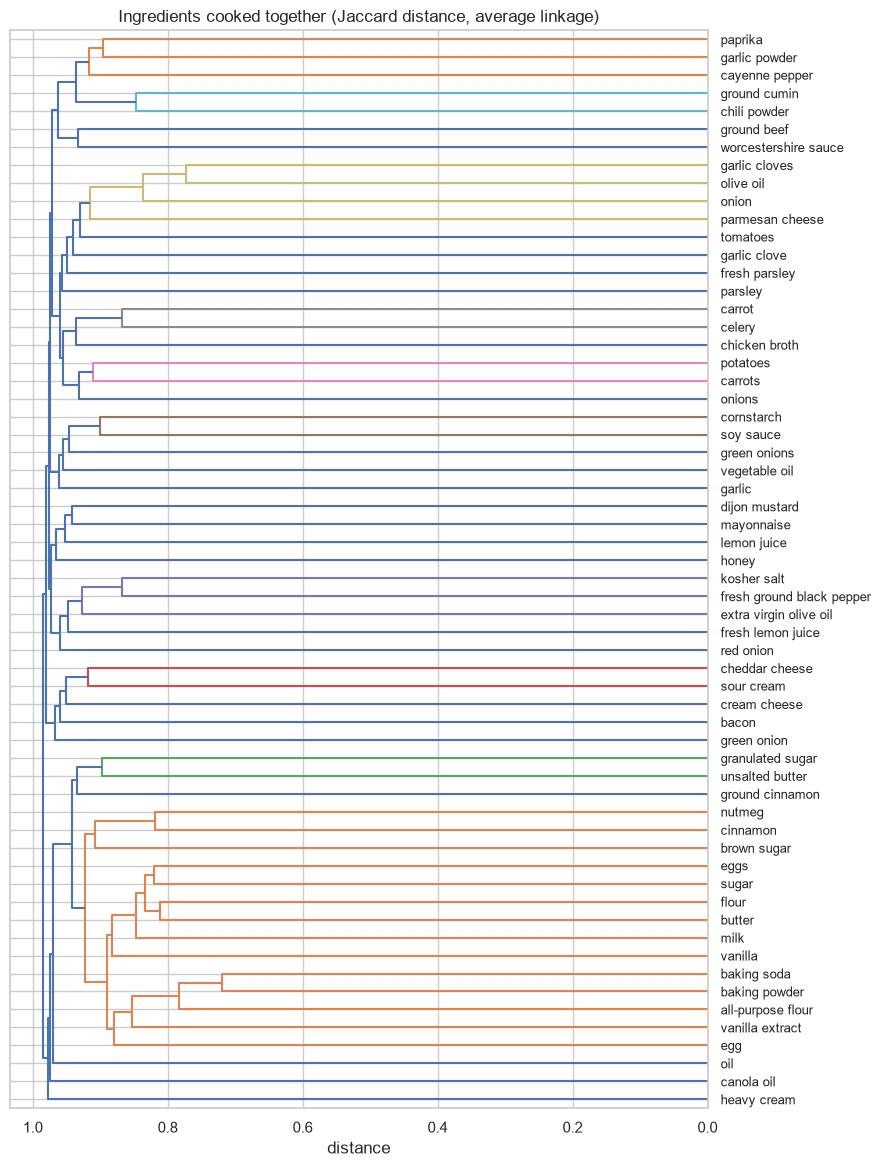

In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.preprocessing import MultiLabelBinarizer

counts = recipes["ingredients"].explode().value_counts()
top = counts.drop(labels=["salt", "water", "pepper", "salt and pepper", "black pepper"], errors="ignore").head(60).index
occurs = MultiLabelBinarizer(classes=list(top)).fit_transform(recipes["ingredients"]).astype(bool)
tree = linkage(pdist(occurs.T, metric="jaccard"), method="average")

fig, ax = plt.subplots(figsize=(9, 14))
dendrogram(tree, labels=list(top), orientation="left", leaf_font_size=9, ax=ax, color_threshold=0.93)
ax.set(title="Ingredients cooked together (Jaccard distance, average linkage)", xlabel="distance")
save(fig, "p5_ingredient_dendrogram")

## Program 6 - PCA of nutrition and SVD of the review matrix

PCA on the standardised nutrient features gives the two-dimensional recipe map
used in the app. Truncated SVD, the same decomposition applied to the sparse
user x recipe matrix, gives the latent factors of the collaborative filter.

first two components explain 65.5% of the variance


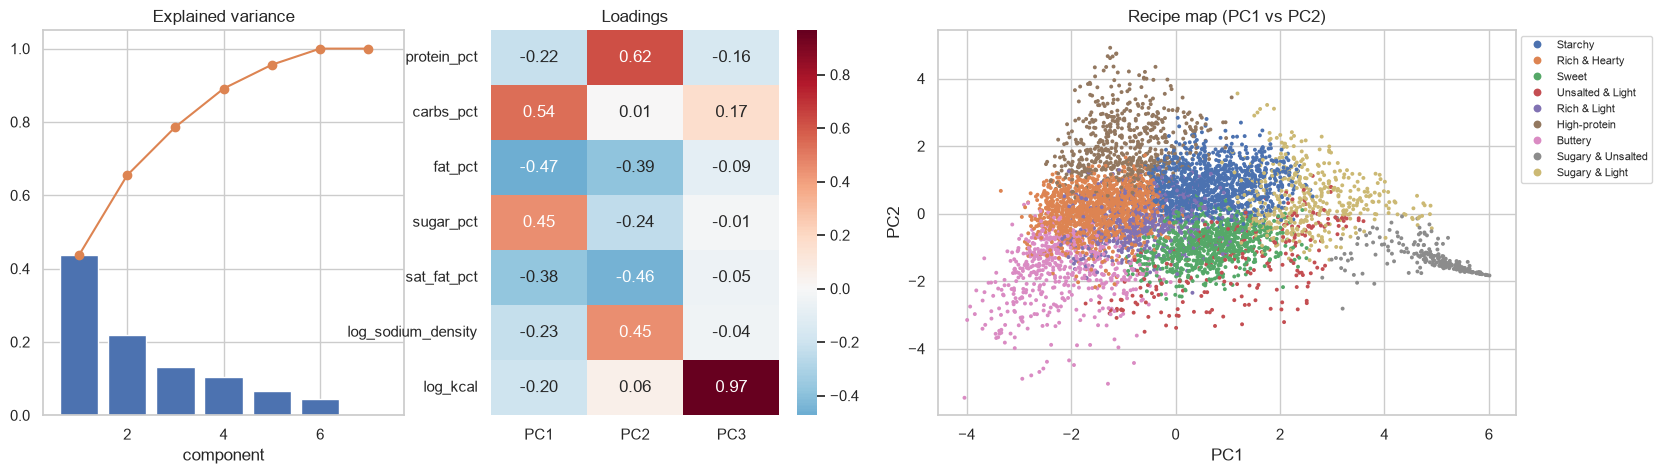

In [23]:
from sklearn.decomposition import PCA, TruncatedSVD

pca = PCA().fit(Z)
loadings = pd.DataFrame(pca.components_[:3].T, index=NUTRIENT_FEATURES, columns=["PC1", "PC2", "PC3"])
xy = archetypes.coordinates(recipes)
recipes["map_x"], recipes["map_y"] = xy[:, 0], xy[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(19, 5), gridspec_kw={"width_ratios": [1, 1, 1.6]})
axes[0].bar(range(1, len(NUTRIENT_FEATURES) + 1), pca.explained_variance_ratio_)
axes[0].plot(range(1, len(NUTRIENT_FEATURES) + 1), np.cumsum(pca.explained_variance_ratio_), marker="o", color="C1")
axes[0].set(title="Explained variance", xlabel="component")
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set(title="Loadings")
pts = recipes.sample(6000, random_state=0)
sns.scatterplot(data=pts, x="map_x", y="map_y", hue="archetype", s=8, linewidth=0, ax=axes[2])
axes[2].set(title="Recipe map (PC1 vs PC2)", xlabel="PC1", ylabel="PC2")
axes[2].legend(markerscale=2, fontsize=8, bbox_to_anchor=(1, 1))
save(fig, "p6_pca")
print(f"first two components explain {pca.explained_variance_ratio_[:2].sum():.1%} of the variance")

matrix 64,643 users x 78,930 recipes, 221,732 non-zeros
64 factors explain 26.8%, 128 explain 36.5%


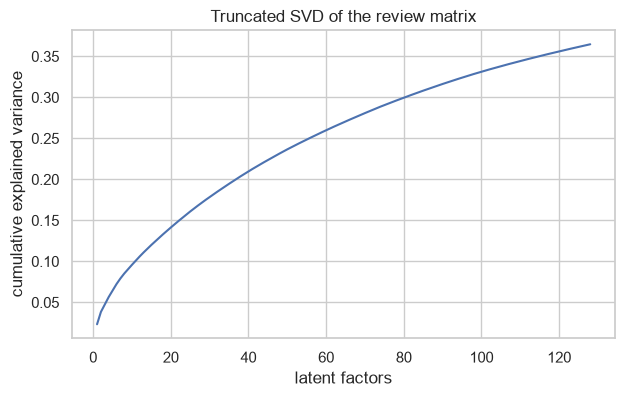

In [24]:
index = ItemIndex(recipes["recipe_id"])
R, users = interaction_matrix(interactions, index)
svd = TruncatedSVD(128, n_iter=7, random_state=42).fit(R)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, 129), np.cumsum(svd.explained_variance_ratio_))
ax.set(title="Truncated SVD of the review matrix", xlabel="latent factors", ylabel="cumulative explained variance")
save(fig, "p6_svd_scree")
print(f"matrix {R.shape[0]:,} users x {R.shape[1]:,} recipes, {R.nnz:,} non-zeros")
print(f"64 factors explain {svd.explained_variance_ratio_[:64].sum():.1%}, 128 explain {svd.explained_variance_ratio_.sum():.1%}")

## Program 7 - Hidden Markov Model of eating phases

For users with at least 20 reviews, the archetype of each reviewed recipe in
date order is treated as an observation emitted by a hidden state, such as a
"baking phase" or a "light cooking phase". A categorical HMM is fitted for 2
to 5 states and chosen by BIC.

In [25]:
from hmmlearn.hmm import CategoricalHMM

long_users = per_user[per_user >= 20].index
seq = inter[inter["user_id"].isin(long_users)].sort_values(["user_id", "date"], kind="stable")
lengths = seq.groupby("user_id", sort=True).size().to_numpy()
obs = seq["archetype"].to_numpy().reshape(-1, 1)

fits = {}
for n in range(2, 6):
    model = CategoricalHMM(n_components=n, n_features=archetypes.k_, n_iter=200, random_state=42)
    model.fit(obs, lengths)
    fits[n] = model
    print(f"{n} states: log-likelihood {model.score(obs, lengths):,.0f}, BIC {model.bic(obs, lengths):,.0f}")
n_states = min(fits, key=lambda n: fits[n].bic(obs, lengths))
hmm = fits[n_states]
print(f"\n{len(lengths)} users, {len(obs):,} reviews, BIC chooses {n_states} states")

2 states: log-likelihood -261,241, BIC 522,705


3 states: log-likelihood -258,702, BIC 517,779


4 states: log-likelihood -258,064, BIC 516,679


5 states: log-likelihood -258,636, BIC 518,024



884 users, 126,304 reviews, BIC chooses 4 states


expected reviews before switching state: state 1: 1.8, state 2: 442.3, state 3: 5.4, state 4: 18.7


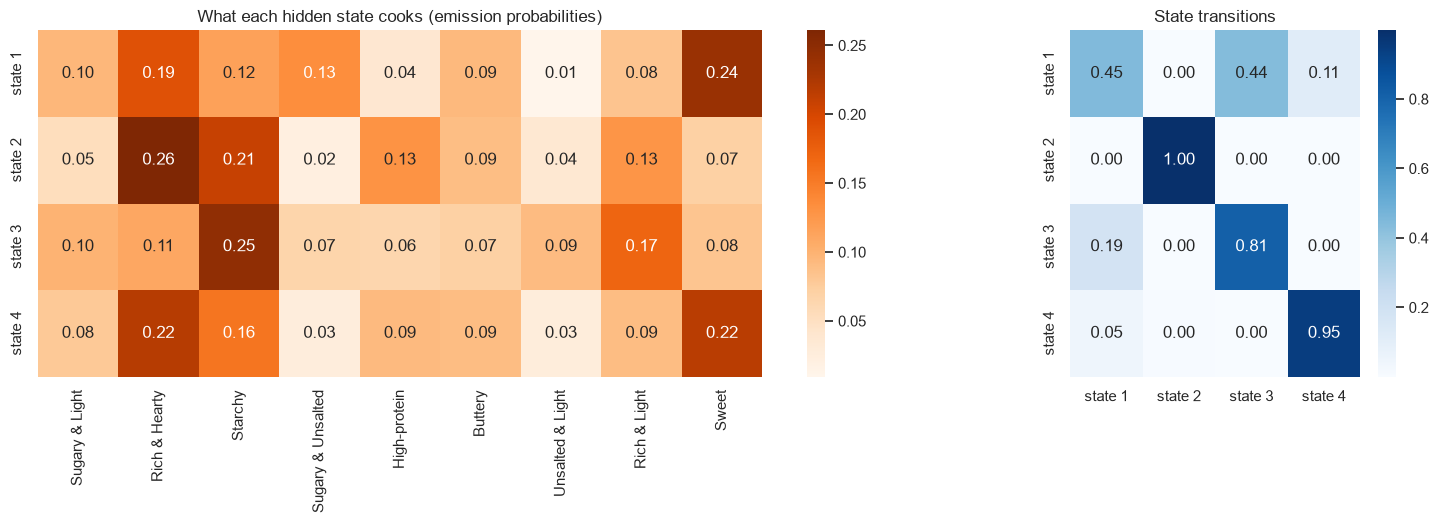

In [26]:
state_names = [f"state {i + 1}" for i in range(n_states)]
emissions = pd.DataFrame(hmm.emissionprob_, index=state_names, columns=archetypes.names_)
transitions = pd.DataFrame(hmm.transmat_, index=state_names, columns=state_names)
fig, axes = plt.subplots(1, 2, figsize=(18, 4.5), gridspec_kw={"width_ratios": [3, 1.2]})
sns.heatmap(emissions, annot=True, fmt=".2f", cmap="Oranges", ax=axes[0])
axes[0].set(title="What each hidden state cooks (emission probabilities)")
sns.heatmap(transitions, annot=True, fmt=".2f", cmap="Blues", ax=axes[1])
axes[1].set(title="State transitions")
save(fig, "p7_hmm")
stay = np.diag(hmm.transmat_)
print("expected reviews before switching state:", ", ".join(f"{s}: {1 / (1 - p):.1f}" for s, p in zip(state_names, stay)))

## Program 8 - CART rules for the archetypes

K-means centroids are hard to read. A shallow decision tree fitted to the
cluster labels turns them into threshold rules; fidelity is how often the tree
agrees with K-means.

In [27]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

Xn = recipes[NUTRIENT_FEATURES].to_numpy()
km_labels = archetypes.predict(recipes)
depth_fidelity = {
    d: (DecisionTreeClassifier(max_depth=d, min_samples_leaf=200, random_state=42).fit(Xn, km_labels).predict(Xn) == km_labels).mean()
    for d in range(1, 9)
}
print(pd.Series(depth_fidelity, name="fidelity").round(3).to_string())
print(f"\nthe app uses depth 4: fidelity {archetypes.tree_fidelity_:.1%}\n")
print(archetypes.rules())

1    0.392
2    0.563
3    0.694
4    0.800
5    0.825
6    0.849
7    0.873
8    0.883

the app uses depth 4: fidelity 80.0%

|--- carbs_pct <= 0.41
|   |--- protein_pct <= 0.35
|   |   |--- log_kcal <= 5.70
|   |   |   |--- sat_fat_pct <= 0.30
|   |   |   |   |--- class: Rich & Light
|   |   |   |--- sat_fat_pct >  0.30
|   |   |   |   |--- class: Buttery
|   |   |--- log_kcal >  5.70
|   |   |   |--- sat_fat_pct <= 0.34
|   |   |   |   |--- class: Rich & Hearty
|   |   |   |--- sat_fat_pct >  0.34
|   |   |   |   |--- class: Buttery
|   |--- protein_pct >  0.35
|   |   |--- fat_pct <= 0.54
|   |   |   |--- log_kcal <= 6.47
|   |   |   |   |--- class: High-protein
|   |   |   |--- log_kcal >  6.47
|   |   |   |   |--- class: High-protein
|   |   |--- fat_pct >  0.54
|   |   |   |--- log_kcal <= 5.89
|   |   |   |   |--- class: High-protein
|   |   |   |--- log_kcal >  5.89
|   |   |   |   |--- class: Rich & Hearty
|--- carbs_pct >  0.41
|   |--- sugar_pct <= 0.20
|   |   |--- log_sod

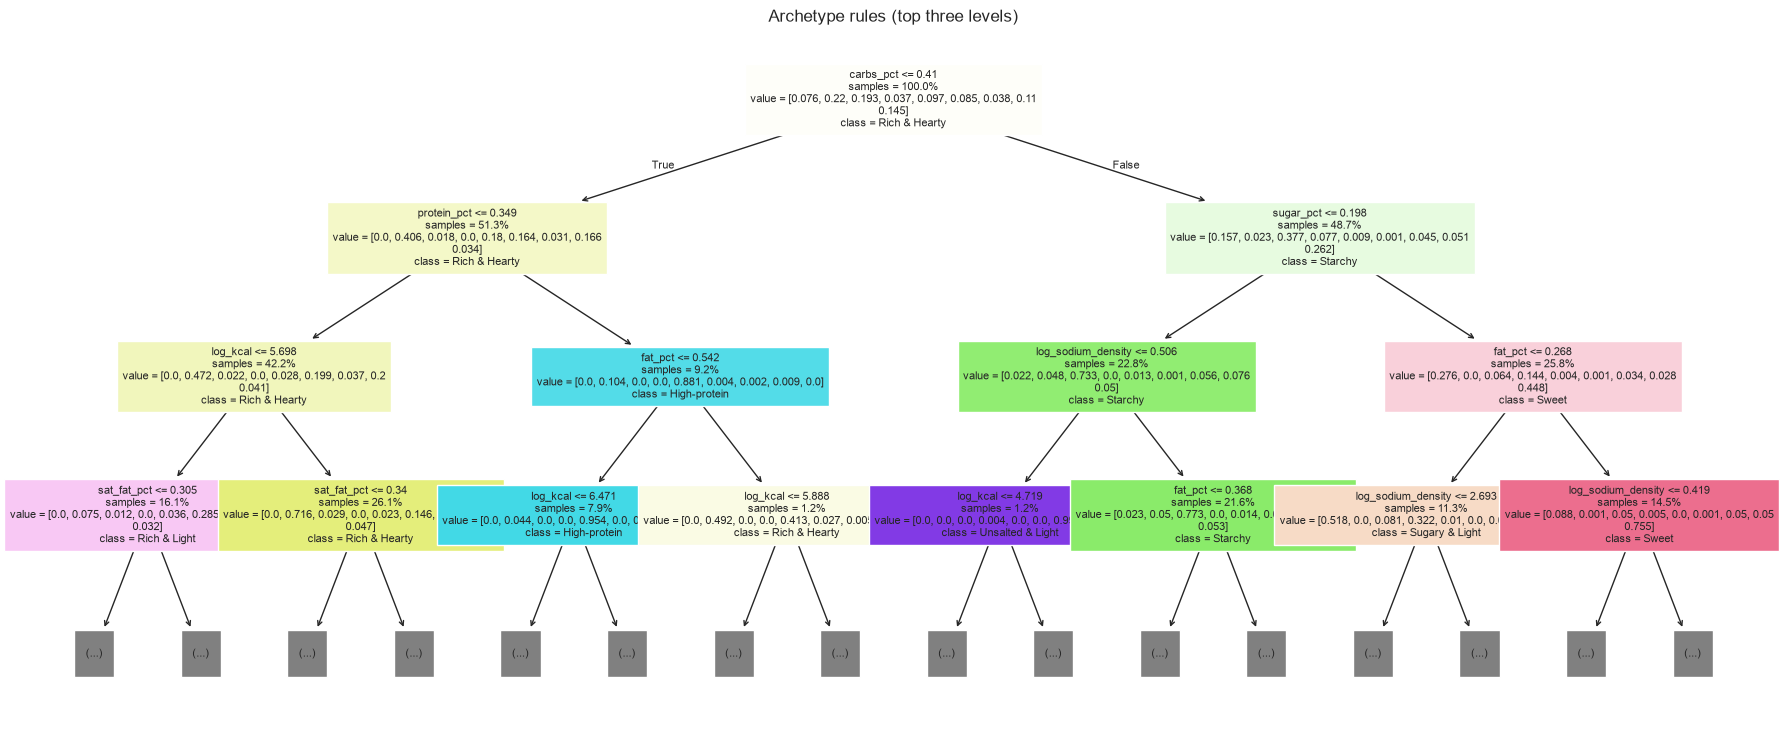

In [28]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(archetypes.tree_, max_depth=3, feature_names=NUTRIENT_FEATURES, class_names=list(archetypes.names_),
          filled=True, impurity=False, proportion=True, fontsize=8, ax=ax)
ax.set_title("Archetype rules (top three levels)")
save(fig, "p8_cart_tree")

## Program 9 - Ensemble learning for recommendation ranking

The recommender has two stages. Four generators score every recipe for a
user: **popularity**, **trending** (reviews in the previous 12 months),
**PureSVD** collaborative filtering and **content** (TF-IDF over ingredients
and tags). The union of each generator's top 50 becomes the candidate set, and
a classifier ranks the candidates using the generator scores, recipe features
and how well each recipe matches the user's past choices.

Evaluation is leave-last-out in time. For every user with at least three
reviewed recipes, the last one is the test target and the one before it the
validation target. Each target is served on the day it was reviewed, and
recipes submitted after that day are never shown. Rankers learn from the
validation targets and are scored on the test targets. Hit rate at 10 is how
often the true next recipe is in the top ten out of 78,930.

In [29]:
ev = Evaluation(recipes, interactions)
rec_eval = ev.fit_recommender(course_col="course_final")
generators = pd.DataFrame(ev.evaluate_generators(rec_eval)).T
print(f"{len(ev.users):,} evaluation users")
train_counts = ev.train.groupby("recipe_id").size()
targets = pd.Series(ev.test_pos).map(lambda p: index.ids[p])
print(f"test targets never reviewed in training: {(~targets.isin(train_counts.index)).mean():.1%}")
generators

6,453 evaluation users
test targets never reviewed in training: 21.3%


,HR@10,NDCG@10,MRR
svd,0.005269,0.003202,0.003326
content,0.010693,0.006943,0.006860
popularity,0.013482,0.006048,0.005638
trending,0.007593,0.003666,0.003799


In [30]:
val = ev.candidate_frame(rec_eval, "val")
test = ev.candidate_frame(rec_eval, "test")
train_rows = sample_negatives(val)
print(f"candidates per user: {len(test) / len(ev.users):.0f}; true next recipe retrieved for {test.groupby('user')['label'].max().mean():.1%} of users")
print(f"ranker training rows: {len(train_rows):,} ({train_rows['label'].sum()} positives)")

results, fitted = {}, {}
for name, model in ranker_models().items():
    model.fit(train_rows[FEATURES], train_rows["label"])
    results[name] = ranking_metrics(pool_ranks(model.predict_proba(test[FEATURES])[:, 1], test, len(ev.users)))
    fitted[name] = model
rankers = pd.DataFrame(results).T
comparison = pd.concat([generators.assign(stage="generator"), rankers.assign(stage="ranker")])
comparison.round(4)

candidates per user: 181; true next recipe retrieved for 8.1% of users
ranker training rows: 15,035 (485 positives)


,HR@10,NDCG@10,MRR,stage
svd,0.0053,0.0032,0.0033,generator
content,0.0107,0.0069,0.0069,generator
popularity,0.0135,0.0060,0.0056,generator
trending,0.0076,0.0037,0.0038,generator
logistic regression,0.0201,0.0119,0.0112,ranker
random forest,0.0373,0.0224,0.0194,ranker
gradient boosting,0.0369,0.0217,0.0186,ranker
soft voting,0.0361,0.0221,0.0194,ranker


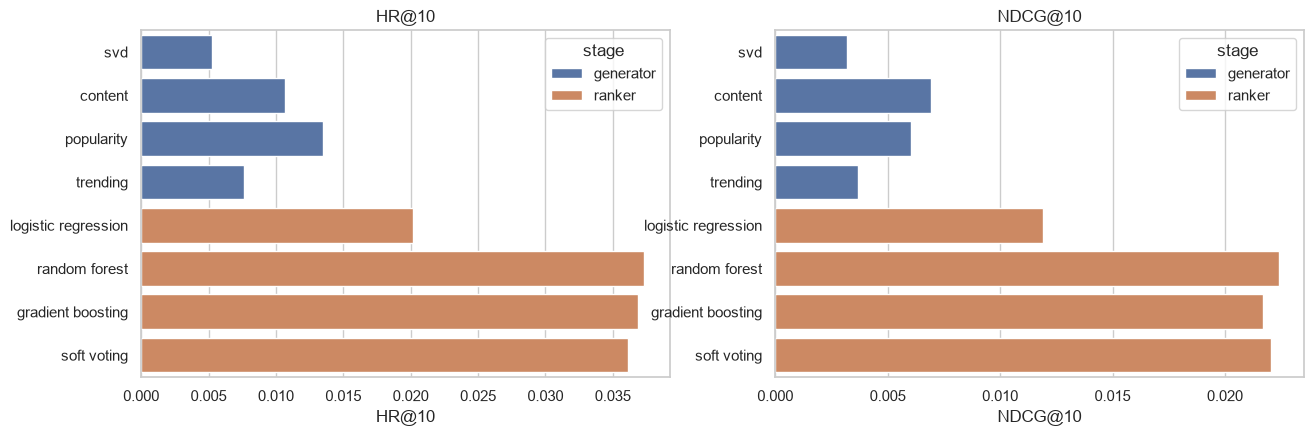

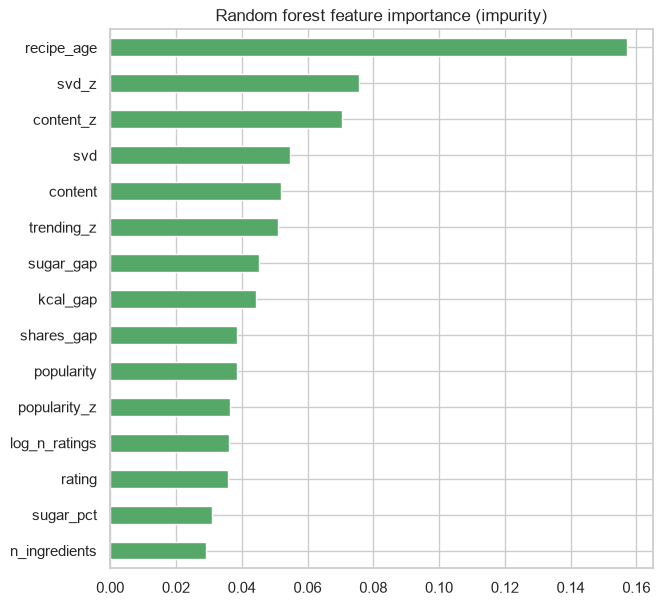

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot = comparison.reset_index(names="model")
for ax, metric in zip(axes, ["HR@10", "NDCG@10"]):
    sns.barplot(data=plot, y="model", x=metric, hue="stage", dodge=False, ax=ax)
    ax.set(title=metric, ylabel="")
save(fig, "p9_model_comparison")

importance = pd.Series(fitted["random forest"].feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
importance.tail(15).plot.barh(ax=ax, color="C2")
ax.set(title="Random forest feature importance (impurity)")
save(fig, "p9_feature_importance")

## Putting it together - a week of meals

A 25-year-old, 175 cm, 70 kg man with light activity who wants to maintain his
weight, and who likes a few curry recipes. Content similarity to those recipes
is the planner's preference; the mixed-integer program chooses a recipe and
portion for every slot of seven days.

In [32]:
target = daily_target(weight=70, height=175, age=25, male=1, activity="light", goal="maintain")
print({k: round(v) for k, v in target.items()})
rec_all = HybridRecommender(recipes, course_col="course_final").fit(interactions)
liked = recipes.loc[recipes["title"].str.contains("Butter Chicken|Chicken Tikka Masala", regex=True), "recipe_id"].head(3).tolist()
print("liked:", recipes.set_index("recipe_id").loc[liked, "title"].tolist())
H = history_matrix([rec_all.index.known_positions(liked)], len(rec_all.index))
preference = pd.Series(rec_all.content.score(H)[0], index=recipes["recipe_id"])
plan, totals = plan_meals(recipes, target, preference, days=7, course_col="course_final")
plan[["day", "slot", "title", "portion", "calories", "protein_g", "carbs_g", "fat_g"]].head(8).round(1)

{'bmr': 1674, 'kcal': 2301, 'protein': 115, 'carbs': 288, 'fat': 77}


liked: ['Chicken Tikka Masala Vegan Style', 'African Style Grilled Peanut Butter Chicken', 'Babzy S Better Butter Chicken Ww 4 Points']


,day,slot,title,portion,calories,protein_g,carbs_g,fat_g
0,0,breakfast,Creamy Chicken And Spinach Pasta,1.0,695.0,49.5,120.0,4.6
1,0,lunch,Indian Curry With Potatoes Chicken And Eggplant,1.0,449.0,23.0,57.0,15.0
2,0,dinner,Chicken Tikka Masala With Seasoned Jasmine Rice,1.5,806.6,40.5,81.0,35.1
3,0,snack,Spicy Indian Eggplant Spread,1.5,300.2,4.5,27.0,21.5
4,1,breakfast,Southern Living 1986 Chicken Enchiladas,1.0,453.2,19.0,48.0,20.2
5,1,lunch,North African Chicken And Couscous,1.0,1119.1,53.0,141.0,37.0
6,1,dinner,Kheema,1.0,509.9,34.5,63.0,12.4
7,1,snack,Moroccan Hummus,0.5,210.0,8.5,36.0,3.9


largest daily gap from target: 5.1%; recipes used: 28 of 28 meals


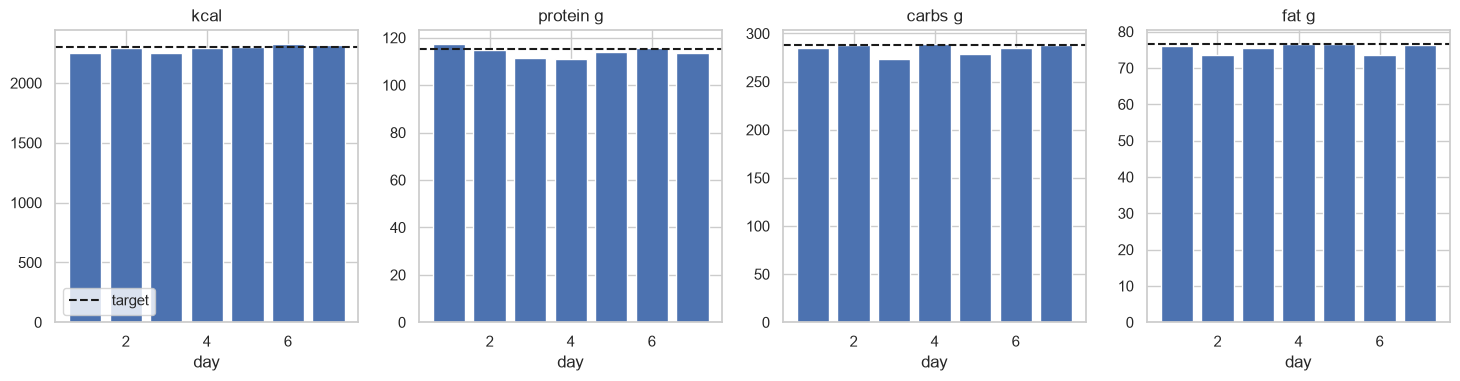

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, (col, label) in zip(axes, [("calories", "kcal"), ("protein_g", "protein g"), ("carbs_g", "carbs g"), ("fat_g", "fat g")]):
    ax.bar(totals["day"] + 1, totals[col], color="C0")
    ax.axhline(totals[f"{col}_target"].iloc[0], color="k", ls="--", label="target")
    ax.set(title=label, xlabel="day")
axes[0].legend()
save(fig, "p10_meal_plan")
gap = (totals[["calories", "protein_g", "carbs_g", "fat_g"]].to_numpy() / totals[["calories_target", "protein_g_target", "carbs_g_target", "fat_g_target"]].to_numpy() - 1)
print(f"largest daily gap from target: {np.abs(gap).max():.1%}; recipes used: {plan['recipe_id'].nunique()} of {len(plan)} meals")

## Results summary

Key numbers from every program, written to `outputs/lab_results.json` for the
project report.

In [34]:
import json
from sklearn.metrics import f1_score

lab_results = {
    "data": {
        "raw_recipes": len(raw_recipes), "recipes": len(recipes),
        "raw_reviews": len(raw_interactions), "reviews": len(interactions),
        "users": int(interactions["user_id"].nunique()), "nhanes_adults": len(nhanes),
        "density": density, "median_reviews_per_recipe": float(per_recipe.median()),
    },
    "cleaning": {k: int(v) for k, v in rules.items()},
    "regression": {
        "test_r2": r2_score(y_test, pred), "test_rmse": mean_squared_error(y_test, pred) ** 0.5,
        "cv_r2": cv.mean(), "formula_r2": r2_score(y_test, formula),
        "formula_rmse": mean_squared_error(y_test, formula) ** 0.5,
        "formula_bias": float((formula - y_test).mean()),
        "coefficients": dict(zip(X.columns, lr.coef_)), "intercept": lr.intercept_,
    },
    "bayes": {
        "n_train": len(ytr), "n_test": len(yte), "dessert_share": float(yte.mean()),
        "accuracy": accuracy_score(yte, p_mean > 0.5), "auc": roc_auc_score(yte, p_mean),
        "posterior": posterior.to_dict(orient="index"),
    },
    "svm": {
        "accuracy": accuracy_score(test_c["course"], pred_c),
        "macro_f1": f1_score(test_c["course"], pred_c, average="macro"),
        "per_class_f1": dict(zip(svm.classes_, f1_score(test_c["course"], pred_c, average=None, labels=svm.classes_))),
        "n_test": len(test_c),
        "filled": int((recipes["course_source"] == "model").sum()),
        "unassigned": int(recipes["course_final"].isna().sum()),
    },
    "kmeans": {
        "k": int(archetypes.k_), "silhouette": {str(k): v for k, v in archetypes.silhouette_.items()},
        "summary": archetypes.summary().to_dict(orient="records"),
    },
    "gmm": {
        "users": len(taste), "k": int(best_k), "k_max": int(max(bic)), "min_bic_k": int(min_bic_k),
        "confident_share": float((resp.max(axis=1) > 0.8).mean()),
        "segments": difference.round(1).to_dict(orient="index"),
    },
    "pca": {"explained_2": float(pca.explained_variance_ratio_[:2].sum()), "loadings": loadings.round(3).to_dict()},
    "svd": {
        "users": R.shape[0], "recipes": R.shape[1], "nnz": int(R.nnz),
        "var_64": float(svd.explained_variance_ratio_[:64].sum()), "var_128": float(svd.explained_variance_ratio_.sum()),
    },
    "hmm": {
        "users": len(lengths), "reviews": len(obs), "states": int(n_states),
        "stay": np.diag(hmm.transmat_).tolist(), "emissions": emissions.round(3).to_dict(orient="index"),
    },
    "cart": {"fidelity_by_depth": {str(d): float(v) for d, v in depth_fidelity.items()}, "fidelity": archetypes.tree_fidelity_},
    "recommender": {
        "users": len(ev.users), "cold_targets": float((~targets.isin(train_counts.index)).mean()),
        "recall": float(test.groupby("user")["label"].max().mean()), "train_rows": len(train_rows),
        "comparison": comparison.drop(columns="stage").to_dict(orient="index"),
        "importance": importance.sort_values(ascending=False).head(10).to_dict(),
    },
    "meal_plan": {"target": target, "max_gap": float(np.abs(gap).max()), "unique": int(plan["recipe_id"].nunique()), "meals": len(plan)},
}
with open(ROOT / "outputs" / "lab_results.json", "w") as f:
    json.dump(lab_results, f, indent=2, default=float)
print(json.dumps({k: lab_results[k] for k in ["regression", "svm", "gmm", "hmm"]}, indent=1, default=float)[:3000])

{
 "regression": {
  "test_r2": 0.1392667814238293,
  "test_rmse": 681.8156108347166,
  "cv_r2": 0.1586550143341244,
  "formula_r2": -0.4683232840830205,
  "formula_rmse": 890.5196385794424,
  "formula_bias": 312.65811762778515,
  "coefficients": {
   "age": -2.518067881954566,
   "male": 309.5503989378902,
   "weight": 1.0246799526403123,
   "height": 15.362315262647428,
   "log_met": 5.675096733239798
  },
  "intercept": -705.0299511693579
 },
 "svm": {
  "accuracy": 0.7564065855404438,
  "macro_f1": 0.674961663686615,
  "per_class_f1": {
   "beverage": 0.8479020979020979,
   "breakfast": 0.5481002425222312,
   "condiment": 0.5281173594132029,
   "dessert": 0.872794800371402,
   "main": 0.8210011356687341,
   "side": 0.6887272727272727,
   "snack": 0.4180887372013652
  },
  "n_test": 13970,
  "filled": 7266,
  "unassigned": 1814
 },
 "gmm": {
  "users": 1680,
  "k": 5,
  "k_max": 10,
  "min_bic_k": 9,
  "confident_share": 0.9511904761904761,
  "segments": {
   "segment 1 (182 users)"

## Conclusion

| Program | Result |
|---|---|
| 1-2 | 78,930 of 83,782 recipes pass the nutrition checks; the review matrix is 0.0043% dense |
| 3 | intake regression CV R² 0.16; the formula sits +313 kcal above reported intake, consistent with under-reporting |
| 4.1 | P(dessert) from nutrition alone: ROC AUC 0.889; wide credible intervals expose the collinear energy shares |
| 4.2 | course SVM accuracy 75.6%, macro F1 0.67; 7,266 missing courses filled |
| 5.1 | 9 nutrition archetypes chosen by silhouette |
| 5.2 | 5 taste segments; 2 show a clear leaning (8+ points on one archetype), the rest sit near the average user |
| 5.3 | baking, Italian-style, spice rub, stir-fry and soup-base ingredient groups recovered without labels |
| 6 | two components explain 65% of nutrient variance; 64 SVD factors explain 27% of the review matrix |
| 7 | 4 hidden states, 3 of them persistent: users cook in runs |
| 8 | a depth-4 tree reproduces 80% of the archetypes as readable rules |
| 9 | random forest ranker HR@10 3.73% against 1.35% for the best generator (popularity) |
| Planner | a 7-day plan with a strong taste preference stays within 5% of every target, no dish repeated |

The recommender's absolute hit rate is limited by the data rather than the
models: 21% of the recipes users cooked next had no
earlier reviews, and candidate retrieval finds the true next recipe for only
8.1% of users. Within what is retrieved, the ensemble ranker
roughly 2.8x the best
single signal, and every tree ensemble clearly beats logistic regression. The
most useful next step is better retrieval, for example a sequence-aware
generator built on the eating phases found in Program 7.